In [81]:
import numpy as np
import torch
import tqdm

from pathlib import Path

import matplotlib.pyplot as plt

from controller.transport_cntrlr import TransportPDController
from controller.mfld_plant_dyn import ManualManifoldPlantDynamics
from manifolds.sn_mfld import HypersphereManifold
from src.episodes.traj import Trajectory
from src.episodes.episode import Episode


In [82]:
EPISODE_DATA_DIR = Path("../data/episodes/hypersphere")
KP_GAIN = 0.7
KD_GAIN = 0.05

In [83]:
episodes = []
for child in EPISODE_DATA_DIR.iterdir():
    if not child.is_file() or child.name == ".gitkeep":
        continue
    episodes.append(Episode.load(child))

In [84]:
for episode_idx, episode in tqdm.tqdm(enumerate(episodes), desc="Episodes", total=len(episodes)):
    # properties associated with the episode
    hs_radius = episode.params["hs_radius"].item()  # needs to be a float
    hs_dim = episode.params["hs_dim"]
    sample_time = episode.params["sample_time"]
    traj_idx = episode.params["traj_idx"]
    episode_idx = episode.params["episode_idx"]

    # constructs hypersphere dynamics of the appropriate dimension to be used with the trajectory
    hypersphere_manifold = HypersphereManifold(hs_dim, hs_radius)
    manifold_dynamics = ManualManifoldPlantDynamics(hypersphere_manifold,
                                                    (episode.initial_pos, episode.initial_vel))

    num_timesteps = episode.target_traj.time.shape[0]
    controller = TransportPDController(manifold_dynamics,
                                       KP_GAIN * np.eye(manifold_dynamics.m),
                                       KD_GAIN * np.eye(manifold_dynamics.m))

    extrinsic_err_hist = []

    for timestep_idx in tqdm.tqdm(range(num_timesteps), desc="Timesteps", total=num_timesteps, leave=True):
        t = manifold_dynamics.time
        chart, (curr_state_pos, curr_state_vel) = manifold_dynamics.current_state
        target_pos, target_vel = episode.target_traj.intrinsic_at_t(chart, t)

        print(
            f"t: {t},\tpos: {curr_state_pos}, vel: {curr_state_vel},\n\ttarget_pos: {target_pos}, target_vel: {target_vel}")

        # measure our tracking error using the extrinsic coordinates
        state_pos_extrinsic = manifold_dynamics.manifold.to_extrinsic(chart, torch.tensor(curr_state_pos))
        target_pos_extrinsic = manifold_dynamics.manifold.to_extrinsic(chart, torch.tensor(target_pos))

        pos_err = target_pos_extrinsic - state_pos_extrinsic
        print(f"\t\tpos_err: {pos_err}")

        extrinsic_err_hist.append(pos_err)

        controls = controller.generate_controls(manifold_dynamics.manifold.default_chart,
                                                (curr_state_pos, curr_state_vel),
                                                (target_pos, target_vel))

        result = manifold_dynamics.step(sample_time, controls)

    break
    pass

Timesteps:   1%|▏         | 13/996 [00:00<00:07, 128.91it/s]


t: 0.0,	pos: [0.09847069], vel: [0.05323092],
	target_pos: [0.23932409], target_vel: [-0.39215058]
		pos_err: tensor([-0.0237,  0.1387])
t: 0.05,	pos: [0.10122482], vel: [0.05693423],
	target_pos: [0.21981955], target_vel: [-0.38804626]
		pos_err: tensor([-0.0189,  0.1170])
t: 0.1,	pos: [0.10414472], vel: [0.05986185],
	target_pos: [0.20051956], target_vel: [-0.38395816]
		pos_err: tensor([-0.0146,  0.0952])
t: 0.15000000000000002,	pos: [0.10719163], vel: [0.06201471],
	target_pos: [0.18142319], target_vel: [-0.37988654]
		pos_err: tensor([-0.0107,  0.0734])
t: 0.2,	pos: [0.11032688], vel: [0.06339513],
	target_pos: [0.16253042], target_vel: [-0.37583122]
		pos_err: tensor([-0.0071,  0.0517])
t: 0.25,	pos: [0.11351193], vel: [0.06400687],
	target_pos: [0.14383984], target_vel: [-0.37179223]
		pos_err: tensor([-0.0039,  0.0301])
t: 0.3,	pos: [0.11670848], vel: [0.06385508],
	target_pos: [0.12535095], target_vel: [-0.36776966]
		pos_err: tensor([-0.0010,  0.0086])
t: 0.35,	pos: [0.119878

Timesteps:   4%|▍         | 40/996 [00:00<00:07, 131.91it/s]

t: 1.3000000000000005,	pos: [0.12893297], vel: [-0.07971163],
	target_pos: [-0.2033639], target_vel: [-0.29074952]
		pos_err: tensor([-0.0123, -0.3305])
t: 1.3500000000000005,	pos: [0.1246304], vel: [-0.09239123],
	target_pos: [-0.2178092], target_vel: [-0.28707016]
		pos_err: tensor([-0.0159, -0.3404])
t: 1.4000000000000006,	pos: [0.11968547], vel: [-0.10540587],
	target_pos: [-0.23207092], target_vel: [-0.28340712]
		pos_err: tensor([-0.0197, -0.3494])
t: 1.4500000000000006,	pos: [0.1140822], vel: [-0.11872508],
	target_pos: [-0.24615002], target_vel: [-0.27976045]
		pos_err: tensor([-0.0236, -0.3575])
t: 1.5000000000000007,	pos: [0.10780612], vel: [-0.13231782],
	target_pos: [-0.26004744], target_vel: [-0.27613011]
		pos_err: tensor([-0.0278, -0.3647])
t: 1.5500000000000007,	pos: [0.10084436], vel: [-0.14615254],
	target_pos: [-0.27376366], target_vel: [-0.27251613]
		pos_err: tensor([-0.0322, -0.3710])
t: 1.6000000000000008,	pos: [0.09318562], vel: [-0.16019723],
	target_pos: [-0.2


Timesteps:   7%|▋         | 68/996 [00:00<00:06, 134.00it/s]

...

t: 46.19999999999951,	pos: [-0.71247873], vel: [-0.47748427],
	target_pos: [-1.32371569], target_vel: [-0.08387155]
		pos_err: tensor([-0.5122, -0.3159])
t: 46.24999999999951,	pos: [-0.73684849], vel: [-0.49730604],
	target_pos: [-1.3279357], target_vel: [-0.08492766]
		pos_err: tensor([-0.5001, -0.2987])
t: 46.29999999999951,	pos: [-0.76219025], vel: [-0.5163643],
	target_pos: [-1.33220816], target_vel: [-0.08599002]
		pos_err: tensor([-0.4870, -0.2812])
t: 46.349999999999504,	pos: [-0.78846496], vel: [-0.53462442],
	target_pos: [-1.3365345], target_vel: [-0.08705866]
		pos_err: tensor([-0.4728, -0.2634])
t: 46.3999999999995,	pos: [-0.81563191], vel: [-0.55205334],
	target_pos: [-1.34091425], target_vel: [-0.08813359]
		pos_err: tensor([-0.4575, -0.2455])
t: 46.4499999999995,	pos: [-0.84364873], vel: [-0.56861948],
	target_pos: [-1.34534788], target_vel: [-0.08921478]
		pos_err: tensor([-0.4412, -0.2276])
t: 46.499999999999496,	pos: [-0.87247154], vel: [-0.58429285],
	target_pos: [-1.


Timesteps:  97%|█████████▋| 969/996 [00:07<00:00, 137.89it/s]

t: 47.59999999999943,	pos: [-1.60808977], vel: [-0.66584784],
	target_pos: [-1.46292114], target_vel: [-0.11581347]
		pos_err: tensor([0.1450, 0.0051])
t: 47.64999999999943,	pos: [-1.64116188], vel: [-0.65703624],
	target_pos: [-1.46874285], target_vel: [-0.11704522]
		pos_err: tensor([0.1722, 0.0027])
t: 47.69999999999943,	pos: [-1.67376756], vel: [-0.64719127],
	target_pos: [-1.47462606], target_vel: [-0.11828324]
		pos_err: tensor([ 0.1988, -0.0007])
t: 47.749999999999424,	pos: [-1.70585566], vel: [-0.63633261],
	target_pos: [-1.48057127], target_vel: [-0.11952752]
		pos_err: tensor([ 0.2248, -0.0050])
t: 47.79999999999942,	pos: [-1.73737602], vel: [-0.62448181],
	target_pos: [-1.48657894], target_vel: [-0.12077808]
		pos_err: tensor([ 0.2499, -0.0103])
t: 47.84999999999942,	pos: [-1.76827963], vel: [-0.61166243],
	target_pos: [-1.49264908], target_vel: [-0.1220349]
		pos_err: tensor([ 0.2743, -0.0164])
t: 47.899999999999416,	pos: [-1.79851868], vel: [-0.59789974],
	target_pos: [-1.


Episodes:   0%|          | 0/11 [00:07<?, ?it/s]

t: 49.04999999999935,	pos: [-2.22544559], vel: [-0.10231746],
	target_pos: [-1.65795708], target_vel: [-0.15408067]
		pos_err: tensor([ 0.5218, -0.2029])
t: 49.09999999999935,	pos: [-2.22993545], vel: [-0.07727696],
	target_pos: [-1.66569662], target_vel: [-0.1554943]
		pos_err: tensor([ 0.5177, -0.2050])
t: 49.149999999999345,	pos: [-2.23317594], vel: [-0.05234251],
	target_pos: [-1.67350674], target_vel: [-0.15691423]
		pos_err: tensor([ 0.5125, -0.2062])
t: 49.19999999999934,	pos: [-2.23517359], vel: [-0.02756344],
	target_pos: [-1.6813879], target_vel: [-0.15834042]
		pos_err: tensor([ 0.5062, -0.2066])
t: 49.24999999999934,	pos: [-2.2359374], vel: [-0.00298885],
	target_pos: [-1.68934107], target_vel: [-0.1597729]
		pos_err: tensor([ 0.4989, -0.2062])
t: 49.299999999999336,	pos: [-2.23547881], vel: [0.02133244],
	target_pos: [-1.69736528], target_vel: [-0.16121162]
		pos_err: tensor([ 0.4906, -0.2049])
t: 49.34999999999933,	pos: [-2.23381169], vel: [0.04535208],
	target_pos: [-1.7

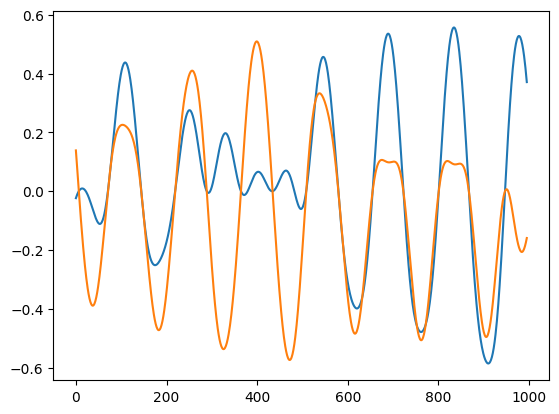

In [85]:
extrinsic_err_hist = np.array(extrinsic_err_hist)


fig, ax = plt.subplots(1,1)
ax.plot(extrinsic_err_hist)
